In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

torch.cuda.is_available()

False

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
mnist = datasets.MNIST(root='./data', train=True, download=True)
x = torch.tensor(mnist.data, dtype=torch.float32)
y = torch.tensor(mnist.targets, dtype=torch.long)
y.shape

100%|██████████| 9.91M/9.91M [00:00<00:00, 148MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 64.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 64.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.09MB/s]
/tmp/ipykernel_22679/1048960306.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(mnist.data, dtype=torch.float32)
/tmp/ipykernel_22679/1048960306.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(mnist.targets, dtype=torch.long)


torch.Size([60000])

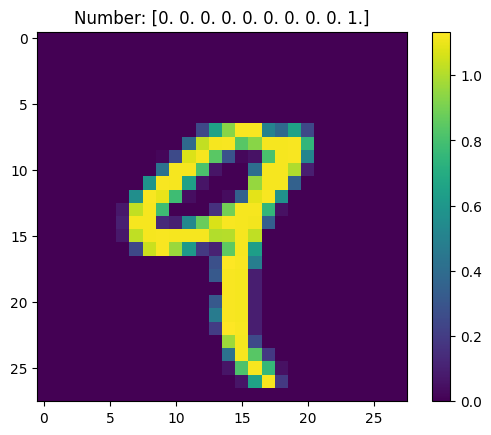

In [22]:
plt.imshow(x[4].numpy())
plt.title(f'Number: {y[4].numpy()}')
plt.colorbar()
plt.show()

In [5]:
y_encoded = F.one_hot(y,num_classes=10)
y_encoded.shape

torch.Size([60000, 10])

In [6]:
x.shape

torch.Size([60000, 28, 28])

In [7]:
x.view(-1,28*28).shape

torch.Size([60000, 784])

In [8]:
class CTDataset(Dataset):
  def __init__(self, filepath):
    self.x, self.y = torch.load(filepath)
    self.x = self.x/225
    self.y = F.one_hot(self.y, num_classes=10).to(float)
  def __len__(self):
    return self.x.shape[0]
  def __getitem__(self, ix):
    return self.x[ix], self.y[ix]

In [28]:
train_ds = CTDataset("/content/drive/MyDrive/Colab Notebooks/datasets/MNIST/processed/training.pt")
test_ds = CTDataset("/content/drive/MyDrive/Colab Notebooks/datasets/MNIST/processed/test.pt")

In [10]:
len(train_ds)

60000

In [11]:
xs, ys = train_ds[0:4]

In [12]:
ys.shape

torch.Size([4, 10])

In [13]:
train_dl = DataLoader(train_ds, batch_size=5)

In [14]:
for x, y in train_dl:
  print(x.shape)
  print(y.shape)
  break

torch.Size([5, 28, 28])
torch.Size([5, 10])


In [15]:
loss = nn.CrossEntropyLoss()

In [16]:
class digitClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(28*28, 100)
    self.layer2 = nn.Linear(100,50)
    self.layer3 = nn.Linear(50,10)
    self.R = nn.ReLU()
  def forward(self, x):
    x = x.view(-1,28*28)
    x = self.R(self.layer1(x))
    x = self.R(self.layer2(x))
    x = self.layer3(x)
    return x.squeeze()

In [17]:
model = digitClassifier()

In [18]:
model(xs)

tensor([[-0.0054,  0.0267, -0.1112,  0.0865,  0.1068,  0.0152, -0.1116,  0.1727,
         -0.0308, -0.0783],
        [ 0.0076,  0.0368, -0.1208,  0.1002,  0.0846,  0.0726, -0.1027,  0.0932,
         -0.0651, -0.0406],
        [ 0.0264,  0.0255, -0.1480,  0.0809,  0.1040,  0.0098, -0.1456,  0.1331,
         -0.0430, -0.0718],
        [-0.0062,  0.0617, -0.1628,  0.0969,  0.0647,  0.0449, -0.1284,  0.1021,
         -0.0392, -0.0889]], grad_fn=<SqueezeBackward0>)

In [19]:
ys

tensor([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=torch.float64)

In [20]:
#training loop
def train_model(dl, f, n_epochs=20):
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
  loss =[]
  epochs = []
  for epoch in range(n_epochs):
    print(f'Epoch: {epoch}')
    N = len(dl)
    for i, (x, y) in enumerate(dl):
      optimizer.zero_grad()
      loss_value = criterion(f(x),y)
      loss_value.backward()
      optimizer.step()
      epochs.append(epoch+i/N)
      loss.append(loss_value.item())
  return np.array(epochs), np.array(loss)

In [21]:
epoch_data, loss_data = train_model(train_dl, model)

Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19


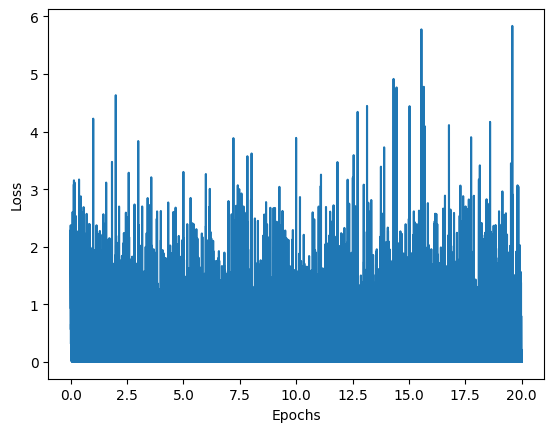

In [24]:
plt.plot(epoch_data, loss_data)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

Text(0.5, 1.0, 'cross entropy avg')

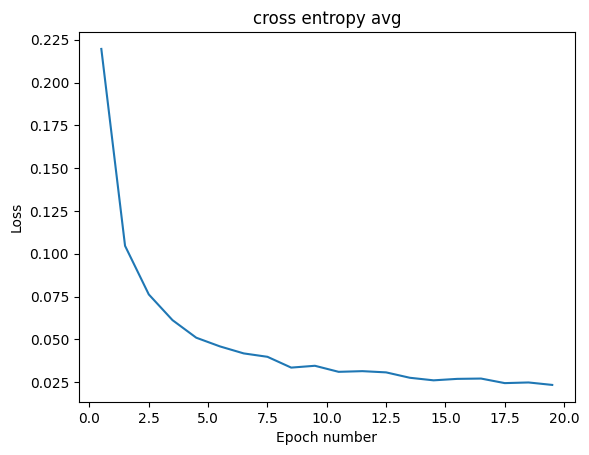

In [26]:
plt.plot(epoch_data.reshape(20, -1).mean(axis=1), loss_data.reshape(20, -1).mean(axis=1))
plt.xlabel('Epoch number')
plt.ylabel('Loss')
plt.title('cross entropy avg')

In [31]:
xs, ys = test_ds[:2000]
yhats = model(xs).argmax(axis=1)

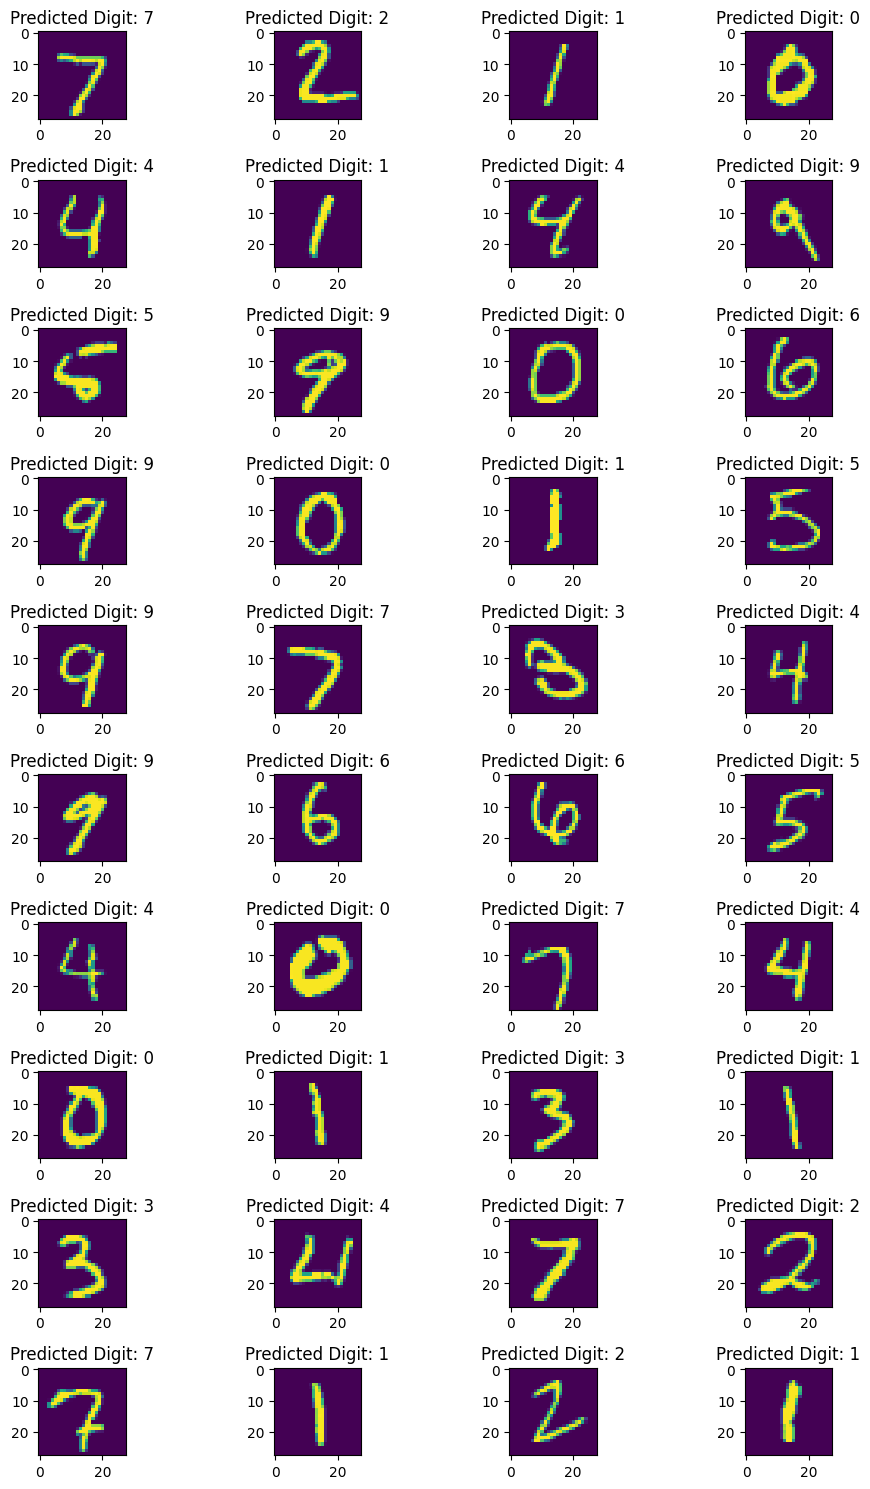

In [33]:
figure, ax = plt.subplots(10,4, figsize=(10,15))
for i in range(40):
  plt.subplot(10,4,i+1)
  plt.imshow(xs[i])
  plt.title(f'Predicted Digit: {yhats[i]}')
figure.tight_layout()
plt.show()